## 1. Data Loading

This section imports the required libraries, defines the dataset path in Kaggle, and loads the main dataset files.
It also reads the CSV file and checks the number of images, masks, and records to make sure the dataset is correctly connected and ready for cleaning.

In [1]:
# Import the required libraries for data loading, cleaning,  preprocessing, and training
import os                          # Used to manage files and folder paths
import cv2                         # Used to read and process images
import pandas as pd                # Used to read and inspect the CSV file
import matplotlib.pyplot as plt    # Used to display images
import xml.etree.ElementTree as ET # Used to read XML annotation files
from PIL import Image              # Used to check if images are valid or corrupted
import shutil                      # Used to copy images and label files
from sklearn.model_selection import train_test_split  # Used to split data into training and validation sets
!pip install ultralytics
from ultralytics import YOLO


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
# Define the dataset path in Kaggle and check the main dataset files

dataset_path = "/kaggle/input/datasets/trainingdatapro/parking-space-detection-dataset"
print("Dataset files:", os.listdir(dataset_path))

Dataset files: ['boxes', 'images', 'parking.csv', 'annotations.xml']


In [3]:
# Define the main file and folder locations inside the dataset

images_path = dataset_path + "/images"          # Folder containing original parking images
boxes_path = dataset_path + "/boxes"            # Folder containing mask/box images
csv_path = dataset_path + "/parking.csv"        # CSV file containing image and mask information
xml_path = dataset_path + "/annotations.xml"    # XML file containing parking space annotations

In [4]:
# Read the CSV file and display the first five rows to inspect the dataset records

df = pd.read_csv(csv_path)
df.head()

,id,image,mask
0,0,images/0.png,boxes/0.png
1,1,images/1.png,boxes/1.png
2,2,images/2.png,boxes/2.png
3,3,images/3.png,boxes/3.png
4,4,images/4.png,boxes/4.png


In [5]:
# Check the number of images, masks, and CSV records

print("Number of images:", len(os.listdir(images_path)))
print("Number of masks:", len(os.listdir(boxes_path)))
print("CSV rows:", len(df))

Number of images: 30
Number of masks: 30
CSV rows: 33


## 2. Data Cleaning
This section checks all parking images to make sure they are readable and not corrupted before using them for model training.

In [6]:
# Check all images to make sure they are readable and not corrupted before preprocessing

valid_images = []
corrupted_images = []

# Loop through each image and verify that it can be opened correctly
for img_name in os.listdir(images_path):
    img_path = os.path.join(images_path, img_name)

    try:
        img = Image.open(img_path)
        img.verify()
        valid_images.append(img_name)
    except Exception:
        corrupted_images.append(img_name)

# Print the cleaning results
print("Total images:", len(os.listdir(images_path)))
print("Valid images:", len(valid_images))
print("Corrupted images:", len(corrupted_images))
print("Corrupted files:", corrupted_images)

Total images: 30
Valid images: 30
Corrupted images: 0
Corrupted files: []


## 3. Data Preprocessing

This section prepares the dataset for YOLO training. It reads the XML annotation file, converts polygon annotations into YOLO TXT label format, splits the images and labels into training and validation sets, and creates the data.yaml configuration file required by YOLO.

In [7]:
# Read the XML annotation file that contains parking space labels and coordinates

tree = ET.parse(xml_path)
root = tree.getroot()

# Print basic information about the XML file
print("Root tag:", root.tag)
print("Number of annotated images:", len(root.findall("image")))

# Display the attributes of the first annotated image to understand the XML structure
first_image = root.findall("image")[0]
print("First image attributes:", first_image.attrib)

Root tag: annotations
Number of annotated images: 30
First image attributes: {'id': '0', 'name': 'images/0.png', 'width': '1200', 'height': '621'}


In [8]:
# Convert XML polygon annotations into YOLO label format

output_labels_path = "/kaggle/working/yolo_labels"
os.makedirs(output_labels_path, exist_ok=True)

# Define class IDs for the two parking space classes
class_map = {
    "free_parking_space": 0,
    "not_free_parking_space": 1
}

# Loop through each image in the XML file and convert its annotations into YOLO labels
for image_tag in root.findall("image"):
    image_name = image_tag.attrib["name"]
    image_width = float(image_tag.attrib["width"])
    image_height = float(image_tag.attrib["height"])

    label_lines = []

    # Loop through each polygon annotation in the current image
    for polygon in image_tag.findall("polygon"):
        label = polygon.attrib["label"]

        if label not in class_map:
            continue

        class_id = class_map[label]
        points = polygon.attrib["points"].split(";")

        x_points = []
        y_points = []

        # Extract all x and y coordinates from the polygon points
        for point in points:
            x, y = point.split(",")
            x_points.append(float(x))
            y_points.append(float(y))

        # Convert polygon coordinates into a rectangular bounding box
        x_min = min(x_points)
        y_min = min(y_points)
        x_max = max(x_points)
        y_max = max(y_points)

        # Normalize bounding box values to match YOLO format
        x_center = ((x_min + x_max) / 2) / image_width
        y_center = ((y_min + y_max) / 2) / image_height
        box_width = (x_max - x_min) / image_width
        box_height = (y_max - y_min) / image_height

        # Save the annotation line in YOLO format: class x_center y_center width height
        label_lines.append(
            f"{class_id} {x_center} {y_center} {box_width} {box_height}"
        )

    # Create a TXT label file with the same name as the image
    txt_name = os.path.splitext(os.path.basename(image_name))[0] + ".txt"
    txt_path = os.path.join(output_labels_path, txt_name)

    # Write all YOLO labels for the current image into the TXT file
    with open(txt_path, "w") as f:
        f.write("\n".join(label_lines))

print("YOLO labels created successfully!")
print("Number of label files:", len(os.listdir(output_labels_path)))

YOLO labels created successfully!
Number of label files: 30


In [9]:
# Split images and labels into training and validation sets

yolo_dataset_path = "/kaggle/working/parking_yolo_dataset"

folders = [
    "images/train", "images/val",
    "labels/train", "labels/val"
]

# Create YOLO folder structure
for folder in folders:
    os.makedirs(os.path.join(yolo_dataset_path, folder), exist_ok=True)

# Split image files into 80% training and 20% validation
image_files = sorted(os.listdir(images_path))

train_files, val_files = train_test_split(
    image_files,
    test_size=0.2,
    random_state=42
)

# Copy images and their matching labels to the correct folder
def copy_files(file_list, split_name):
    for img_name in file_list:
        label_name = os.path.splitext(img_name)[0] + ".txt"

        shutil.copy(
            os.path.join(images_path, img_name),
            os.path.join(yolo_dataset_path, "images", split_name, img_name)
        )

        shutil.copy(
            os.path.join(output_labels_path, label_name),
            os.path.join(yolo_dataset_path, "labels", split_name, label_name)
        )

copy_files(train_files, "train")
copy_files(val_files, "val")

print("Training images:", len(train_files))
print("Validation images:", len(val_files))


Training images: 24
Validation images: 6


In [10]:
# Create a data.yaml file that tells YOLO where the training and validation images are located,
# and defines the number and names of the parking space classes.

yaml_content = """
train: /kaggle/working/parking_yolo_dataset/images/train
val: /kaggle/working/parking_yolo_dataset/images/val

nc: 2
names:
  0: free_parking_space
  1: not_free_parking_space
"""

# Save the data.yaml file inside the prepared YOLO dataset folder
yaml_path = "/kaggle/working/parking_yolo_dataset/data.yaml"

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print("data.yaml created successfully!")
print("YAML file path:", yaml_path)

data.yaml created successfully!
YAML file path: /kaggle/working/parking_yolo_dataset/data.yaml


In [11]:
# Verify that the YOLO dataset folders were created correctly

print("Main YOLO dataset folders:", os.listdir("/kaggle/working/parking_yolo_dataset"))
print("Image folders:", os.listdir("/kaggle/working/parking_yolo_dataset/images"))
print("Label folders:", os.listdir("/kaggle/working/parking_yolo_dataset/labels"))

Main YOLO dataset folders: ['labels', 'data.yaml', 'images']
Image folders: ['train', 'val']
Label folders: ['train', 'val']


## 4. Model Training (Baseline Fine-Tuning)

In [12]:
# Train YOLOv8 nano model for 20 epochs as a baseline experiment

model_20 = YOLO("yolov8n.pt")

results_20 = model_20.train(
    data="/kaggle/working/parking_yolo_dataset/data.yaml",
    epochs=20,      # Baseline training rounds
    imgsz=640,      # Resize input images to 640x640
    batch=8,        # Number of images processed together
    name="parking_baseline_yolov8n_20epochs"
)

Ultralytics 8.4.70 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/parking_yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=parking_baseline_yolov8n_20epochs, nbs=64, nms=False, opset=None, optimize=False, opti

In [13]:
# Load a pre-trained YOLOv8 nano model
model = YOLO("yolov8n.pt")

# Train the YOLO model on our parking dataset
results = model.train(
    # Path to the YAML file that tells YOLO where the training and validation images are
    data="/kaggle/working/parking_yolo_dataset/data.yaml",
    epochs=50, # Number of training rounds
    imgsz=640, # Resize all input images to 640x640 during training
    batch=8,# Number of images processed together in one training step
    # YOLO will save the results under this folder name
    name="parking_baseline_yolov8n_50epochs" 
)


Ultralytics 8.4.70 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/parking_yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=parking_baseline_yolov8n_50epochs, nbs=64, nms=False, opset=None, optimize=False, opti

## 5. Model Evaluation 

In [14]:
# Evaluate the 20-epoch YOLO model on the validation dataset
model_20_eval = YOLO("/kaggle/working/runs/detect/parking_baseline_yolov8n_20epochs/weights/best.pt")

metrics_20 = model_20_eval.val(
    data="/kaggle/working/parking_yolo_dataset/data.yaml"
)

# Print the evaluation scores for the 20-epoch model
print("20 Epochs Results")
print("Precision:", metrics_20.box.mp)      # Precision measures how many detected parking spaces were correctly predicted
print("Recall:", metrics_20.box.mr)         # Recall measures how many real parking spaces were successfully detected
print("mAP50:", metrics_20.box.map50)       # Measures overall object detection accuracy at IoU 0.50
print("mAP50-95:", metrics_20.box.map)      # Measures detection performance with stricter evaluation

Ultralytics 8.4.70 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2548.5±662.2 MB/s, size: 145.7 KB)
val: Scanning /kaggle/working/parking_yolo_dataset/labels/val.cache... 6 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6/6 1.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.0s/it 1.0s
                   all          6        232        0.4      0.294      0.459      0.328
    free_parking_space          6         89          0          0      0.113     0.0863
not_free_parking_space          6        143        0.8      0.588      0.804       0.57
Speed: 1.0ms preprocess, 137.4ms inference, 0.0ms loss, 25.3ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
20 Epochs Results
Precision: 0.40002542998825563
Recall: 0.2938005447117167
mAP50:

In [15]:
# Evaluate the trained YOLO model on the validation dataset
metrics = model.val()

# Print the Precision score
print("Precision:", metrics.box.mp)# Precision measures how many detected parking spaces were predicted correctly
print("Recall:", metrics.box.mr)# Recall measures how many real parking spaces were successfully detected by the model
print("mAP50:", metrics.box.map50)# Measures overall object detection accuracy
print("mAP50-95:", metrics.box.map)# Measures detection performance with stricter evaluation

Ultralytics 8.4.70 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2777.3±677.8 MB/s, size: 198.1 KB)
val: Scanning /kaggle/working/parking_yolo_dataset/labels/val.cache... 6 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6/6 1.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.0s/it 1.0s
                   all          6        232      0.849       0.84      0.901      0.695
    free_parking_space          6         89      0.854      0.723      0.831      0.629
not_free_parking_space          6        143      0.843      0.958      0.971      0.762
Speed: 1.0ms preprocess, 135.6ms inference, 0.0ms loss, 19.9ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-2
Precision: 0.8486989872559765
Recall: 0.8403840230528126
mAP50: 0.90076190094661

In [16]:
# Create a comparison table between the 20-epoch and 50-epoch models

comparison_table = {
    "Model": ["YOLOv8n Baseline", "YOLOv8n Improved"],
    "Epochs": [20, 50],
    "Precision": [metrics_20.box.mp, metrics.box.mp],
    "Recall": [metrics_20.box.mr, metrics.box.mr],
    "mAP50": [metrics_20.box.map50, metrics.box.map50],
    "mAP50-95": [metrics_20.box.map, metrics.box.map]
}

df_comparison = pd.DataFrame(comparison_table)
df_comparison

,Model,Epochs,Precision,Recall,mAP50,mAP50-95
0,YOLOv8n Baseline,20,0.400025,0.293801,0.458654,0.327882
1,YOLOv8n Improved,50,0.848699,0.840384,0.900762,0.695373


## 6. Training Results Visualization

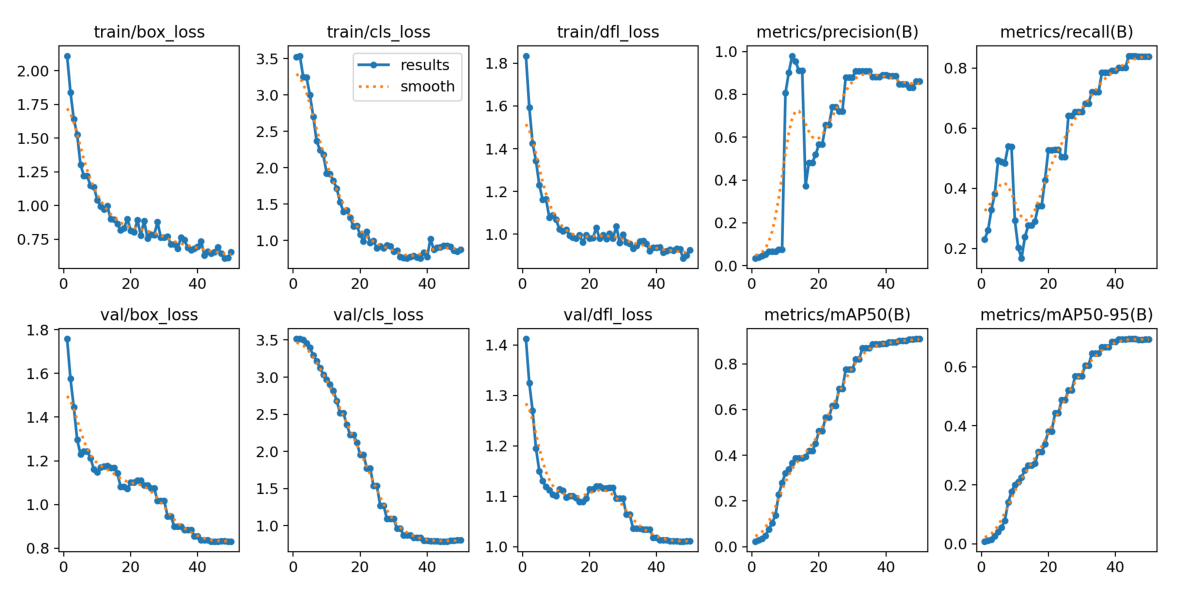

In [17]:
# Path to the training results image generated by YOLO
results_path = "/kaggle/working/runs/detect/parking_baseline_yolov8n_50epochs/results.png"

results_img = cv2.imread(results_path)# Read the results image
# Convert image colors from BGR to RGB for correct display
results_img = cv2.cvtColor(results_img, cv2.COLOR_BGR2RGB)

# Display the training results image
plt.figure(figsize=(15,10))
plt.imshow(results_img)
plt.axis("off")
plt.show()

## 7.Prediction & Testing


image 1/1 /kaggle/working/parking_yolo_dataset/images/val/31.png: 384x640 13 free_parking_spaces, 11 not_free_parking_spaces, 110.2ms
Speed: 3.1ms preprocess, 110.2ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)


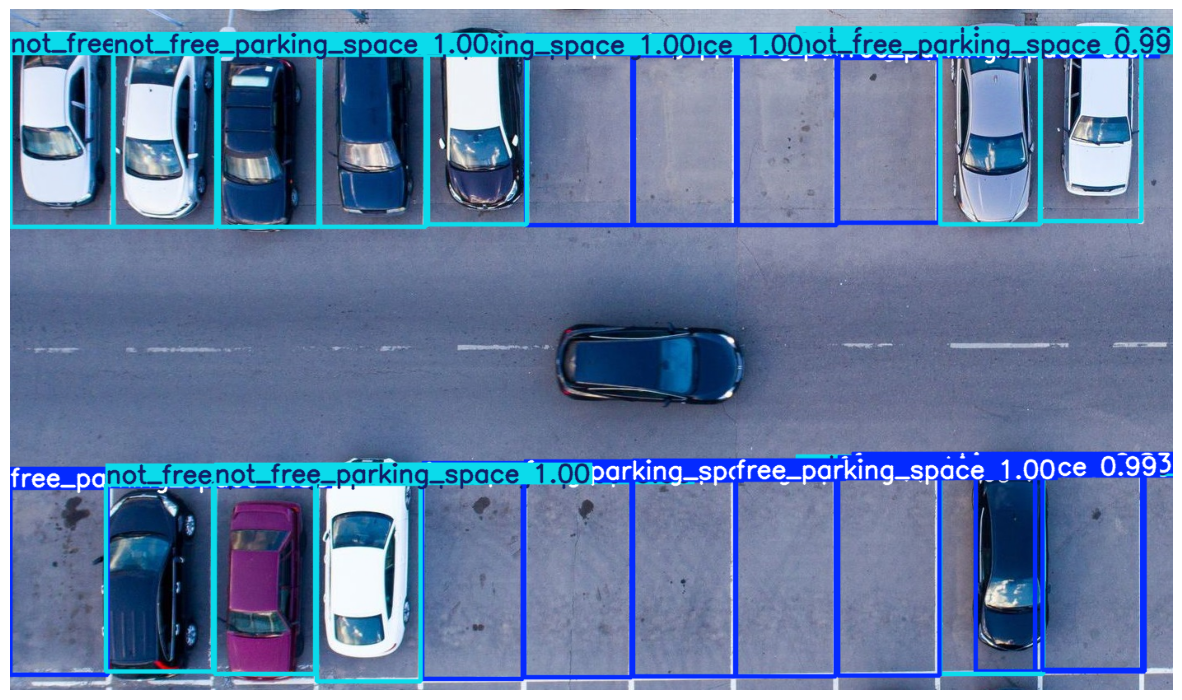

In [18]:
# "best.pt" contains the weights of the model that achieved the best performance during training
model = YOLO("/kaggle/working/runs/detect/parking_baseline_yolov8n_50epochs/weights/best.pt")

# Select one image from the validation dataset for testing
# Here we selected the third image using index [2]
image_path = "/kaggle/working/parking_yolo_dataset/images/val/" + os.listdir("/kaggle/working/parking_yolo_dataset/images/val")[2]

# Prediction
results = model.predict(source=image_path, conf=0.25)# conf=0.25 means the model will display detections with confidence greater than 25%

# Draw the prediction results
result_img = results[0].plot()
# Convert image colors from BGR to RGB for correct display in Matplotlib
result_img = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

# Display the predicted image
plt.figure(figsize=(15,10))
plt.imshow(result_img)
plt.axis("off")
plt.show()

# Load/Stress + Scalability

In [19]:
import time
import os
from ultralytics import YOLO

# Load the best trained model
model = YOLO("/kaggle/working/runs/detect/parking_baseline_yolov8n_50epochs/weights/best.pt")

# Validation images folder
val_images_path = "/kaggle/working/parking_yolo_dataset/images/val"
image_files = os.listdir(val_images_path)

prediction_times = []

# Run prediction on multiple images
for image_name in image_files:
    image_path = os.path.join(val_images_path, image_name)

    start_time = time.time()
    model.predict(source=image_path, conf=0.25, verbose=False)
    end_time = time.time()

    prediction_times.append(end_time - start_time)

# Calculate performance results
average_time = sum(prediction_times) / len(prediction_times)
fastest_time = min(prediction_times)
slowest_time = max(prediction_times)

print("Number of tested images:", len(image_files))
print("Average prediction time:", average_time, "seconds")
print("Fastest prediction time:", fastest_time, "seconds")
print("Slowest prediction time:", slowest_time, "seconds")

Number of tested images: 6
Average prediction time: 0.13114964962005615 seconds
Fastest prediction time: 0.10248279571533203 seconds
Slowest prediction time: 0.16867733001708984 seconds


In [20]:
import os

print("Train Images:", len(os.listdir("/kaggle/working/parking_yolo_dataset/images/train")))
print("Validation Images:", len(os.listdir("/kaggle/working/parking_yolo_dataset/images/val")))

Train Images: 24
Validation Images: 6


In [21]:
import time

total_runs = 20
all_times = []

for run in range(total_runs):
    start_time = time.time()

    for image_name in image_files:
        image_path = os.path.join(val_images_path, image_name)
        model.predict(source=image_path, conf=0.25, verbose=False)

    end_time = time.time()
    all_times.append(end_time - start_time)

print("Stress Test Runs:", total_runs)
print("Average Run Time:", sum(all_times)/len(all_times), "seconds")
print("Minimum Run Time:", min(all_times), "seconds")
print("Maximum Run Time:", max(all_times), "seconds")
print("Total Predictions:", total_runs * len(image_files))

Stress Test Runs: 20
Average Run Time: 0.6623592615127564 seconds
Minimum Run Time: 0.6488380432128906 seconds
Maximum Run Time: 0.6949634552001953 seconds
Total Predictions: 120


# Monitoring + Logging

In [22]:
import os
import time
import pandas as pd
from ultralytics import YOLO

# Load the trained YOLO model
model_path = "/kaggle/working/runs/detect/parking_baseline_yolov8n_50epochs/weights/best.pt"
model = YOLO(model_path)

# Validation images folder
test_images_dir = "/kaggle/working/parking_yolo_dataset/images/val"

# Output log file
log_file = "/kaggle/working/monitoring_log.csv"

# Threshold for prediction time warning
TIME_THRESHOLD = 0.20

logs = []

# Get all validation images
image_files = [
    f for f in os.listdir(test_images_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Run prediction and collect monitoring logs
for image_name in image_files:
    image_path = os.path.join(test_images_dir, image_name)

    start_time = time.time()
    results = model.predict(source=image_path, conf=0.25, verbose=False)
    prediction_time = time.time() - start_time

    number_of_detections = len(results[0].boxes)

    if prediction_time > TIME_THRESHOLD:
        status = "Warning: High prediction time"
    else:
        status = "OK"

    logs.append({
        "image_name": image_name,
        "prediction_time_seconds": round(prediction_time, 4),
        "number_of_detections": number_of_detections,
        "status": status
    })

# Save logs into CSV file
log_df = pd.DataFrame(logs)
log_df.to_csv(log_file, index=False)

print("Monitoring log saved successfully!")
display(log_df)


# Monitoring Summary

summary = {
    "total_images_tested": len(log_df),
    "average_prediction_time_seconds": round(log_df["prediction_time_seconds"].mean(), 4),
    "fastest_prediction_time_seconds": round(log_df["prediction_time_seconds"].min(), 4),
    "slowest_prediction_time_seconds": round(log_df["prediction_time_seconds"].max(), 4),
    "total_detections": int(log_df["number_of_detections"].sum()),
    "warnings_count": int((log_df["status"] != "OK").sum())
}

summary_df = pd.DataFrame([summary])

print("Monitoring Summary:")
display(summary_df)

Monitoring log saved successfully!


,image_name,prediction_time_seconds,number_of_detections,status
0,26.png,0.1472,83,OK
1,24.png,0.0938,36,OK
2,31.png,0.1085,24,OK
3,18.png,0.1209,34,OK
4,17.png,0.1518,22,OK
5,6.png,0.1030,97,OK


Monitoring Summary:


,total_images_tested,average_prediction_time_seconds,fastest_prediction_time_seconds,slowest_prediction_time_seconds,total_detections,warnings_count
0,6,0.1209,0.0938,0.1518,296,0


In [23]:
# Function to check if an image exists and is readable
def load_image_safely(image_path):
    try:
        # Attempt to read the image using OpenCV
        img = cv2.imread(image_path)

        # Check if the image was loaded successfully (img will be None if not)
        if img is None:
            raise FileNotFoundError(f"Image not found or corrupted at {image_path}")

        print(f"Successfully loaded image: {image_path}")
        return img
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return None

# --- Test Cases for Image Loading ---

# Define the validation images directory
val_images_dir = "/kaggle/working/parking_yolo_dataset/images/val/"

# Test with an existing image
if os.path.exists(val_images_dir) and os.listdir(val_images_dir):
    existing_image_path = os.path.join(val_images_dir, os.listdir(val_images_dir)[0])
    loaded_img = load_image_safely(existing_image_path)
else:
    print(f"Validation image directory not found or is empty: {val_images_dir}. Cannot test existing image loading.")

# Test with a non-existent image path
non_existent_image_path = "/kaggle/working/parking_yolo_dataset/images/val/non_existent_image_test.png"
loaded_img_fail = load_image_safely(non_existent_image_path)


Successfully loaded image: /kaggle/working/parking_yolo_dataset/images/val/26.png
Error loading image /kaggle/working/parking_yolo_dataset/images/val/non_existent_image_test.png: Image not found or corrupted at /kaggle/working/parking_yolo_dataset/images/val/non_existent_image_test.png


[ WARN:0@1039.600] global loadsave.cpp:278 findDecoder imread_('/kaggle/working/parking_yolo_dataset/images/val/non_existent_image_test.png'): can't open/read file: check file path/integrity


In [24]:
from ultralytics import YOLO # Import YOLO inside the function to ensure it's available

# Function to safely load a YOLO model
def load_model_safely(model_path):
    try:
        # Attempt to load the YOLO model
        model = YOLO(model_path)
        print(f"Successfully loaded model from: {model_path}")
        return model
    except Exception as e:
        print(f"Error loading model from {model_path}: {e}")
        return None

# --- Test Cases for Model Loading ---

# Define the path to the best trained model (from previous sections)
best_model_path = "/kaggle/working/runs/detect/parking_baseline_yolov8n_50epochs/weights/best.pt"

# Test with an existing model path
if os.path.exists(best_model_path):
    loaded_yolo_model = load_model_safely(best_model_path)
else:
    print(f"Trained model not found at: {best_model_path}. Cannot test existing model loading.")

# Test with a non-existent model path
non_existent_model_path = "/kaggle/working/non_existent_model.pt"
loaded_yolo_model_fail = load_model_safely(non_existent_model_path)

Successfully loaded model from: /kaggle/working/runs/detect/parking_baseline_yolov8n_50epochs/weights/best.pt
Error loading model from /kaggle/working/non_existent_model.pt: [Errno 2] No such file or directory: '/kaggle/working/non_existent_model.pt'


Successfully loaded model from: /kaggle/working/runs/detect/parking_baseline_yolov8n_50epochs/weights/best.pt
Successfully loaded image: /kaggle/working/parking_yolo_dataset/images/val/26.png

Attempting prediction on 26.png...

image 1/1 /kaggle/working/parking_yolo_dataset/images/val/26.png: 448x640 32 free_parking_spaces, 51 not_free_parking_spaces, 106.5ms
Speed: 3.3ms preprocess, 106.5ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)


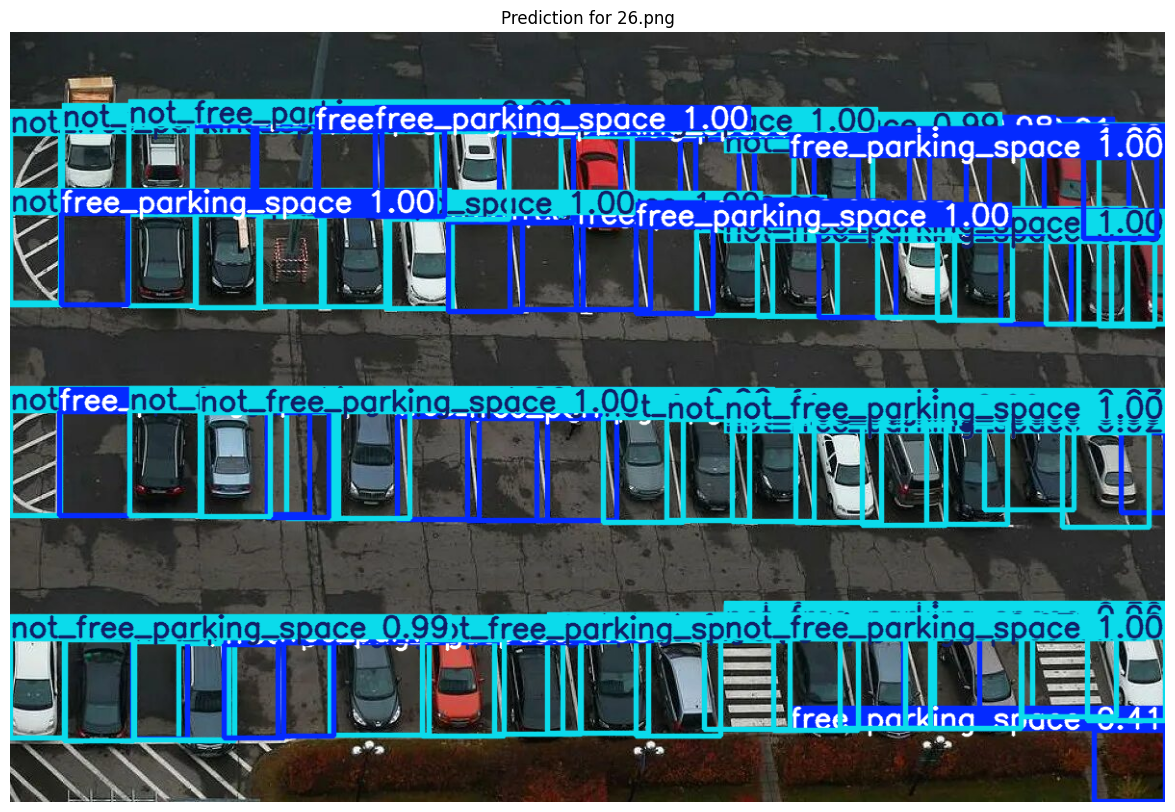

In [25]:
# Define the path to the best trained model
best_model_path = "/kaggle/working/runs/detect/parking_baseline_yolov8n_50epochs/weights/best.pt"

# Safely load the YOLO model
model = load_model_safely(best_model_path)

# Proceed with predictions only if the model was loaded successfully
if model is not None:
    # Define the validation images directory
    val_images_dir = "/kaggle/working/parking_yolo_dataset/images/val/"

    # Get a list of validation image files
    validation_image_files = os.listdir(val_images_dir)

    if validation_image_files:
        # Select one image from the validation dataset for testing (e.g., the first one)
        image_to_test = validation_image_files[0]
        image_path = os.path.join(val_images_dir, image_to_test)

        # Safely load the image
        loaded_img = load_image_safely(image_path)

        if loaded_img is not None:
            print(f"\nAttempting prediction on {image_to_test}...")
            try:
                # Perform prediction
                results = model.predict(source=image_path, conf=0.25)

                # Draw the prediction results
                result_img = results[0].plot()
                # Convert image colors from BGR to RGB for correct display in Matplotlib
                result_img = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

                # Display the predicted image
                plt.figure(figsize=(15, 10))
                plt.imshow(result_img)
                plt.title(f"Prediction for {image_to_test}")
                plt.axis("off")
                plt.show()
            except Exception as e:
                print(f"Error during prediction for {image_to_test}: {e}")
        else:
            print(f"Skipping prediction because image {image_to_test} could not be loaded safely.")
    else:
        print("No images found in the validation directory for testing.")
else:
    print("Skipping predictions because the model could not be loaded safely.")